# A/B Testing: Live In-Class Experiment

This notebook is designed for **live teaching**.  
Rerun the **parameter cell** to generate a fresh randomized experiment each time.

**Teaching goals**
- show how random assignment creates comparable groups
- estimate lift with a simple difference in means
- verify that OLS gives the same estimate
- explore power, sampling noise, and the danger of peeking


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

## 1. Instructor parameter cell

Change only this cell before class.  
A new seed gives you a new experiment. Students should not see the hidden `true_lift` until after discussion.


In [8]:
seed = 2026
n_per_group = 400
baseline_rate = 0.20
true_lift = 0.03          # hidden from students at first
alpha = 0.05

rng = np.random.default_rng(seed)

In [6]:
def make_experiment(seed, n_per_group=400, baseline_rate=0.20, true_lift=0.03):
    rng = np.random.default_rng(seed)
    treat = np.r_[np.zeros(n_per_group, dtype=int), np.ones(n_per_group, dtype=int)]
    p = np.where(treat == 1, baseline_rate + true_lift, baseline_rate)
    y = rng.binomial(1, p)
    df = pd.DataFrame({
        "unit": np.arange(len(treat)),
        "treat": treat,
        "y": y
    })
    df["group"] = np.where(df["treat"] == 1, "Treatment", "Control")
    return df

def summarize_ab(df, alpha=0.05):
    g = df.groupby("treat")["y"]
    mean_c = g.mean().loc[0]
    mean_t = g.mean().loc[1]
    n_c = g.size().loc[0]
    n_t = g.size().loc[1]
    lift = mean_t - mean_c
    se = np.sqrt(mean_t*(1-mean_t)/n_t + mean_c*(1-mean_c)/n_c)
    z = stats.norm.ppf(1 - alpha/2)
    ci_low = lift - z*se
    ci_high = lift + z*se
    z_stat = lift / se if se > 0 else np.nan
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat))) if se > 0 else np.nan
    return pd.DataFrame({
        "control_mean": [mean_c],
        "treatment_mean": [mean_t],
        "lift": [lift],
        "se": [se],
        "ci_low": [ci_low],
        "ci_high": [ci_high],
        "p_value": [p_value]
    })

def run_many_experiments(n_sims=2000, n_per_group=400, baseline_rate=0.20, true_lift=0.03, seed=2026):
    rng = np.random.default_rng(seed)
    lifts = np.empty(n_sims)
    for s in range(n_sims):
        c = rng.binomial(1, baseline_rate, n_per_group)
        t = rng.binomial(1, baseline_rate + true_lift, n_per_group)
        lifts[s] = t.mean() - c.mean()
    return lifts

def approximate_mde(n_per_group, sigma=0.45, alpha=0.05, power=0.80):
    z_alpha = stats.norm.ppf(1 - alpha/2)
    z_power = stats.norm.ppf(power)
    return (z_alpha + z_power) * sigma * np.sqrt(2 / n_per_group)

def peeking_false_positive_rate(n_total=1000, looks=10, sims=1500, seed=2026):
    rng = np.random.default_rng(seed)
    checkpoints = np.unique(np.linspace(50, n_total, looks, dtype=int))
    false_positive = 0
    for _ in range(sims):
        c = rng.normal(0, 1, n_total)
        t = rng.normal(0, 1, n_total)
        hit = False
        for k in checkpoints:
            diff = t[:k].mean() - c[:k].mean()
            se = np.sqrt(t[:k].var(ddof=1)/k + c[:k].var(ddof=1)/k)
            z = diff / se
            if abs(z) > 1.96:
                hit = True
                break
        false_positive += int(hit)
    return false_positive / sims

## 2. Generate a fresh experiment

1. Which version do you think will win?
3. Is a small difference enough to be convincing?


In [8]:
df = make_experiment(seed, n_per_group, baseline_rate, true_lift)
df.head()

,unit,treat,y,group
0,0,0,0,Control
1,1,0,0,Control
2,2,0,0,Control
3,3,0,0,Control
4,4,0,0,Control


In [9]:
group_summary = (
    df.groupby("group")
      .agg(users=("y", "size"), conversions=("y", "sum"), conversion_rate=("y", "mean"))
      .reset_index()
)
group_summary

,group,users,conversions,conversion_rate
0,Control,400,74,0.1850
1,Treatment,400,109,0.2725


## 3. Estimate the treatment effect

This is the core A/B test estimate:
\[
\hat\tau = \bar Y_{treat} - \bar Y_{control}
\]


In [11]:
results = summarize_ab(df, alpha=alpha)
results.style.format({
    "control_mean": "{:.3%}",
    "treatment_mean": "{:.3%}",
    "lift": "{:.3%}",
    "se": "{:.3%}",
    "ci_low": "{:.3%}",
    "ci_high": "{:.3%}",
    "p_value": "{:.4f}",
})

,control_mean,treatment_mean,lift,se,ci_low,ci_high,p_value
0,18.500%,27.250%,8.750%,2.954%,2.960%,14.540%,0.0031


### Discussion prompt

- Is the estimated lift economically meaningful?
- Is it statistically precise?
- Would you ship the treatment?


## 4. Regression equivalence

In a basic randomized experiment, the OLS coefficient on the treatment indicator equals the difference in means.


In [14]:
if HAS_STATSMODELS:
    reg = smf.ols("y ~ treat", data=df).fit()
    print(reg.summary().tables[1])
else:
    print("statsmodels not available; use the difference in means above.")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1850      0.021      8.846      0.000       0.144       0.226
treat          0.0875      0.030      2.958      0.003       0.029       0.146


In [15]:
mean_t = df.loc[df.treat == 1, "y"].mean()
mean_c = df.loc[df.treat == 0, "y"].mean()
lift = mean_t - mean_c

print(f"Difference in means: {lift:.4%}")
if HAS_STATSMODELS:
    print(f"OLS coefficient on treat: {reg.params['treat']:.4%}")

Difference in means: 8.7500%
OLS coefficient on treat: 8.7500%


## 5. Repeated experiments: sampling noise

Even with a true positive effect, some experiments will look large and some small.


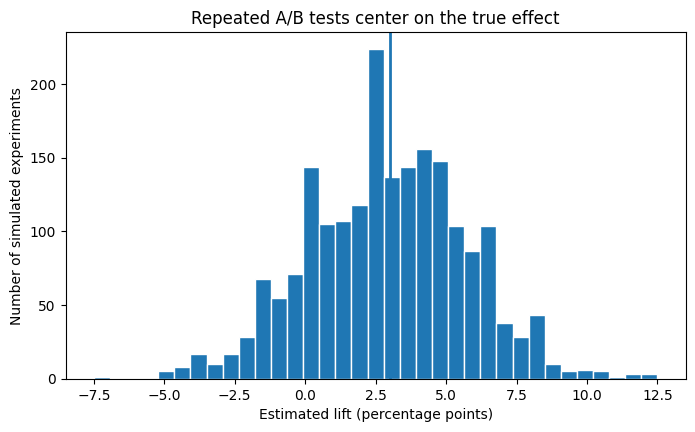

In [17]:
lifts = run_many_experiments(
    n_sims=2000,
    n_per_group=n_per_group,
    baseline_rate=baseline_rate,
    true_lift=true_lift,
    seed=seed
)

plt.figure(figsize=(8, 4.5))
plt.hist(lifts * 100, bins=35, edgecolor="white")
plt.axvline(true_lift * 100, linewidth=2)
plt.xlabel("Estimated lift (percentage points)")
plt.ylabel("Number of simulated experiments")
plt.title("Repeated A/B tests center on the true effect")
plt.show()

## 6. Power and minimum detectable effects

Change the sample size and see what happens to the **minimum detectable effect**.


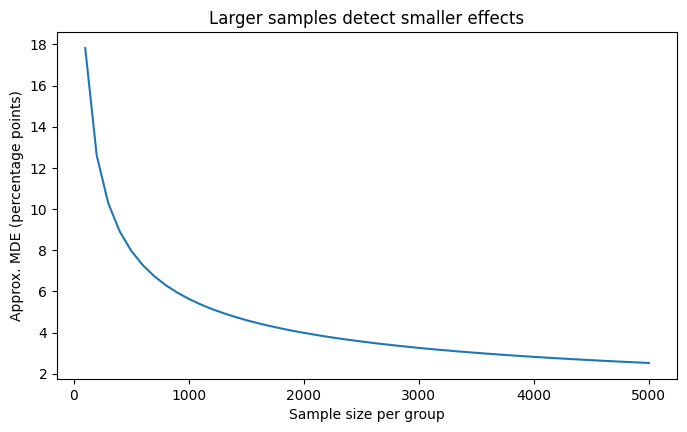

In [19]:
sample_sizes = np.arange(100, 5100, 100)
mde = np.array([approximate_mde(n) for n in sample_sizes])

plt.figure(figsize=(8, 4.5))
plt.plot(sample_sizes, mde * 100)
plt.xlabel("Sample size per group")
plt.ylabel("Approx. MDE (percentage points)")
plt.title("Larger samples detect smaller effects")
plt.show()

In [20]:
for n in [200, 500, 1000, 2500]:
    print(f"n = {n:>4} per group  ->  approx. MDE = {approximate_mde(n):.2%}")

n =  200 per group  ->  approx. MDE = 12.61%
n =  500 per group  ->  approx. MDE = 7.97%
n = 1000 per group  ->  approx. MDE = 5.64%
n = 2500 per group  ->  approx. MDE = 3.57%


## 7. Peeking problem

If you repeatedly check the data and stop when `p < 0.05`, your false positive rate can rise a lot.


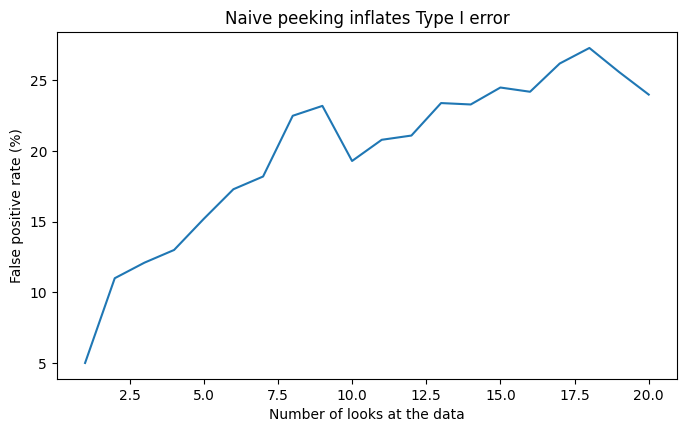

In [22]:
looks_grid = np.arange(1, 21)
fp_rates = [peeking_false_positive_rate(looks=int(k), sims=1000, seed=seed + int(k)) for k in looks_grid]

plt.figure(figsize=(8, 4.5))
plt.plot(looks_grid, np.array(fp_rates) * 100)
plt.xlabel("Number of looks at the data")
plt.ylabel("False positive rate (%)")
plt.title("Naive peeking inflates Type I error")
plt.show()

## 8. Reveal the hidden truth

Use this **after** the class discussion.


In [24]:
print(f"Hidden true lift used to generate the experiment: {true_lift:.1%}")

Hidden true lift used to generate the experiment: 3.0%


## 9. Optional extensions

- Add baseline covariates and compare adjusted vs unadjusted estimates
- Introduce noncompliance and distinguish ITT from treatment-on-treated
- Let outcomes be revenue instead of binary conversion
- Bridge to text: imagine the outcome is open-ended feedback instead of a number


## 10. Instructor checklist

Before class:
- set a new seed
- decide whether students should see the code or only the outputs
- pick a “ship / do not ship” decision rule

During class:
- ask for a prediction before showing results
- make students interpret the confidence interval
- ask why OLS and the raw difference match

After class:
- rerun with a smaller effect and discuss power
- rerun with more looks and discuss peeking
